# ***Custom Grid Setup(static)***

---



---



In [ ]:
#Grid Size
ROWS = 5
COLS = 5

In [ ]:
#Empty grid
grid = [['-' for _ in range(COLS)] for _ in range(ROWS)]

In [ ]:
grid

[['-', '-', '-', '-', '-'],
 ['-', '-', '-', '-', '-'],
 ['-', '-', '-', '-', '-'],
 ['-', '-', '-', '-', '-'],
 ['-', '-', '-', '-', '-']]

In [ ]:
grid[0][0] = 'S'   # Start
grid[0][1] = 'B'   # Button
grid[0][2] = 'M'   # Menu
grid[0][3] = 'F'   # Form
grid[2][2] = 'C'   # Crash (bug)
grid[3][4] = 'G'   # Goal
grid[4][4] = 'E'   # Exit

In [ ]:
blocked = [(0,4),(1,4),(2,4),(4,0),(4,1),(4,2),(4,3)]
for r,c in blocked:
    grid[r][c] = 'X'

In [ ]:
for row in grid:
    print(row)

['S', 'B', 'M', 'F', 'X']
['-', '-', '-', '-', 'X']
['-', '-', 'C', '-', 'X']
['-', '-', '-', '-', 'G']
['X', 'X', 'X', 'X', 'E']


In [ ]:
agent_pos = [0,0]   # start at S

In [ ]:
actions = {
    0: (-1,0),  # up
    1: (1,0),   # down
    2: (0,-1),  # left
    3: (0,1)    # right
}

In [ ]:
#Defining Moving Function

def move(pos, action):
    r, c = pos
    dr, dc = action
    new_r, new_c = r + dr, c + dc

    if 0 <= new_r < ROWS and 0 <= new_c < COLS:
        if grid[new_r][new_c] != 'X':
            return [new_r, new_c]

    return pos

# ***RL training on GUI Grid***

---



---


In [ ]:
import numpy as np
import random

# -----------------------------
# 1. Create GUI Grid Environment
# -----------------------------
grid = [
['S','B','M','F','X'],
['-','-','-','-','X'],
['-','-','C','-','X'],
['-','-','-','-','G'],
['X','X','X','X','E']
]

ROWS = len(grid)
COLS = len(grid[0])

# -----------------------------
# 2. Actions
# -----------------------------
actions = {
    0: (-1,0),  # up
    1: (1,0),   # down
    2: (0,-1),  # left
    3: (0,1)    # right
}

# -----------------------------
# 3. Parameters
# -----------------------------
alpha = 0.1        # learning rate
gamma = 0.8        # discount factor
epsilon = 0.2      # exploration
episodes = 500

# -----------------------------
# 4. Q-table
# -----------------------------
Q = np.zeros((ROWS, COLS, len(actions)))

# -----------------------------
# 5. Reward Function
# -----------------------------
def get_reward(r, c):
    if grid[r][c] == 'C':   # crash/bug
        return 10
    elif grid[r][c] == 'G': # goal
        return 5
    elif grid[r][c] == 'X': # blocked
        return -2
    else:
        return -1

# -----------------------------
# 6. Move Agent
# -----------------------------
def move(r, c, action):
    dr, dc = actions[action]
    new_r = r + dr
    new_c = c + dc

    if 0 <= new_r < ROWS and 0 <= new_c < COLS:
        if grid[new_r][new_c] != 'X':
            return new_r, new_c

    return r, c

# -----------------------------
# 7. Training
# -----------------------------
for episode in range(episodes):

    r, c = 0, 0   # start at S

    for step in range(100):

        # epsilon-greedy
        if random.uniform(0,1) < epsilon:
            action = random.choice(list(actions.keys()))
        else:
            action = np.argmax(Q[r, c])

        new_r, new_c = move(r, c, action)

        reward = get_reward(new_r, new_c)

        # Q-learning update
        Q[r, c, action] = Q[r, c, action] + alpha * (
            reward + gamma * np.max(Q[new_r, new_c]) - Q[r, c, action]
        )

        r, c = new_r, new_c

        # stop if goal reached
        if grid[r][c] == 'G':
            break

# -----------------------------
# 8. Learned Policy
# -----------------------------
policy = np.full((ROWS, COLS), ' ')

symbols = {
    0: '↑',
    1: '↓',
    2: '←',
    3: '→'
}

for r in range(ROWS):
    for c in range(COLS):
        if grid[r][c] not in ['X','G','C']:
            best_action = np.argmax(Q[r,c])
            policy[r,c] = symbols[best_action]
        else:
            policy[r,c] = grid[r][c]

# -----------------------------
# 9. Print Results
# -----------------------------
print("Grid:")
for row in grid:
    print(row)

print("\nLearned Policy:")
for row in policy:
    print(row)

Grid:
['S', 'B', 'M', 'F', 'X']
['-', '-', '-', '-', 'X']
['-', '-', 'C', '-', 'X']
['-', '-', '-', '-', 'G']
['X', 'X', 'X', 'X', 'E']

Learned Policy:
['→' '→' '↓' '↓' 'X']
['↓' '→' '↓' '←' 'X']
['→' '→' 'C' '←' 'X']
['→' '↑' '↑' '↑' 'G']
['X' 'X' 'X' 'X' '↑']


In [ ]:
import time
import numpy as np
import random

grid = [
['S','-','-','-','X'],
['-','-','-','-','X'],
['-','-','C','-','X'],
['-','-','-','-','G'],
['X','X','X','X','E']
]

ROWS, COLS = 5,5

actions = [( -1,0 ), (1,0), (0,-1), (0,1)]

def print_grid(r,c):
    for i in range(ROWS):
        row=""
        for j in range(COLS):
            if i==r and j==c:
                row+="A "
            else:
                row+=grid[i][j]+" "
        print(row)
    print()

r,c = 0,0

for step in range(10):
    print(f"Step {step}")
    print_grid(r,c)
    time.sleep(1)

    action = random.choice(actions)
    nr = r + action[0]
    nc = c + action[1]

    if 0<=nr<ROWS and 0<=nc<COLS and grid[nr][nc]!="X":
        r,c = nr,nc

Step 0
A - - - X 
- - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 1
S A - - X 
- - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 2
S - - - X 
- A - - X 
- - C - X 
- - - - G 
X X X X E 

Step 3
S - - - X 
- - A - X 
- - C - X 
- - - - G 
X X X X E 

Step 4
S - A - X 
- - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 5
S - A - X 
- - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 6
S - A - X 
- - - - X 
- - C - X 
- - - - G 
X X X X E 

Step 7
S - - - X 
- - A - X 
- - C - X 
- - - - G 
X X X X E 

Step 8
S - - - X 
- - - - X 
- - A - X 
- - - - G 
X X X X E 

Step 9
S - - - X 
- - - - X 
- - C A X 
- - - - G 
X X X X E 



In [ ]:
symbols = {0:'↑', 1:'↓', 2:'←', 3:'→'}

policy = []
for r in range(ROWS):
    row = []
    for c in range(COLS):
        if grid[r][c] in ['X','C','G','E']:
            row.append(grid[r][c])
        else:
            best = np.argmax(Q[r,c])
            row.append(symbols[best])
    policy.append(row)

for row in policy:
    print(row)

['→', '→', '↓', '↓', 'X']
['↓', '→', '↓', '←', 'X']
['→', '→', 'C', '←', 'X']
['→', '↑', '↑', '↑', 'G']
['X', 'X', 'X', 'X', 'E']


In [ ]:
r,c = 0,0

for step in range(15):
    print("Step:", step, ": Position:", (r,c))
    action = np.argmax(Q[r,c])
    r,c = move(r,c,action)

    if grid[r][c] in ['C','G']:
        print("Reached:", grid[r][c])
        break

Step: 0 : Position: (0, 0)
Step: 1 : Position: (0, 1)
Step: 2 : Position: (0, 2)
Step: 3 : Position: (1, 2)
Reached: C


In [ ]:
def steps_rl():
    r,c=0,0
    for i in range(50):
        action = np.argmax(Q[r,c])
        r,c = move(r,c,action)
        if grid[r][c] in ['C','G']:
            return i
    return 50

print("Avg steps RL:", np.mean([steps_rl() for _ in range(50)]))

Avg steps RL: 3.0


In [ ]:
def random_agent():
    r,c = 0,0
    total = 0
    for _ in range(50):
        action = random.randint(0,3)
        r,c = move(r,c,action)
        total += get_reward(r,c)
    return total

In [ ]:
rl_scores = []
rand_scores = []

for _ in range(100):
    # RL
    r,c = 0,0
    total = 0
    for _ in range(50):
        action = np.argmax(Q[r,c])
        r,c = move(r,c,action)
        total += get_reward(r,c)
    rl_scores.append(total)

    rand_scores.append(random_agent())

print("RL avg:", np.mean(rl_scores))
print("Random avg:", np.mean(rand_scores))

RL avg: 214.0
Random avg: -17.79


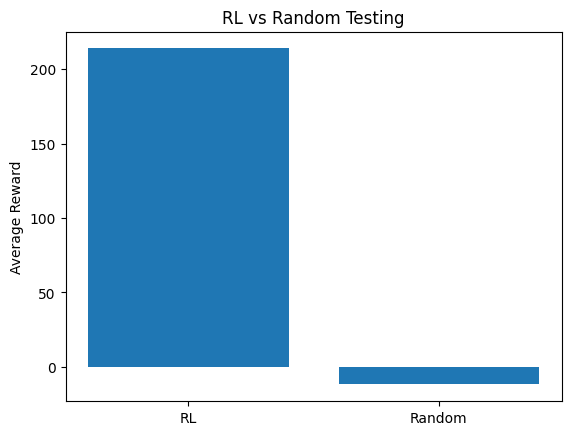

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(['RL','Random'], [214.0, -11.87])
plt.ylabel("Average Reward")
plt.title("RL vs Random Testing")
plt.show()

In [ ]:
action = random.randint(0,3)

In [ ]:
actions = [0,1,2,3]

In [ ]:
action = random.choice(actions)

In [ ]:
actions = {
    0: (-1,0),
    1: (1,0),
    2: (0,-1),
    3: (0,1)
}

In [ ]:
action = random.choice(list(actions.keys()))

In [ ]:
episode_rewards = []

In [ ]:
for episode in range(episodes):

    r, c = 0, 0
    total_reward = 0

    for step in range(100):

        if random.uniform(0,1) < epsilon:
            action = random.choice(list(actions.keys()))
        else:
            action = np.argmax(Q[r, c])

        new_r, new_c = move(r, c, action)
        reward = get_reward(new_r, new_c)

        Q[r, c, action] = Q[r, c, action] + alpha * (
            reward + gamma * np.max(Q[new_r, new_c]) - Q[r, c, action]
        )

        r, c = new_r, new_c
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)

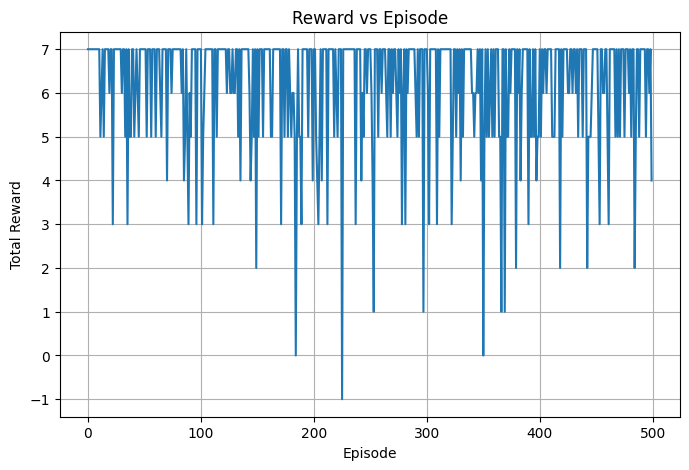

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(episode_rewards)
plt.grid()
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward vs Episode")
plt.show()

In [ ]:
visited=set()
visited.add((r,c))

In [ ]:
#epsilon = max(0.01, epsilon*0.995)

In [ ]:
visited = set()

for episode in range(episodes):
    r,c = 0,0

    for step in range(50):

        visited.add((r,c))   # track visited state

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        r,c = move(r,c,action)

In [ ]:
print("Unique states visited:", len(visited))

Unique states visited: 17


In [ ]:
coverage = []
visited = set()

for episode in range(episodes):
    r,c = 0,0

    for step in range(50):
        visited.add((r,c))

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        r,c = move(r,c,action)

    coverage.append(len(visited))

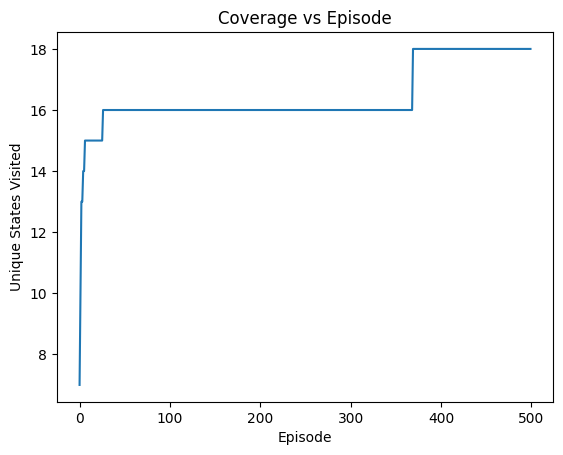

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(coverage)
plt.xlabel("Episode")
plt.ylabel("Unique States Visited")
plt.title("Coverage vs Episode")
plt.show()

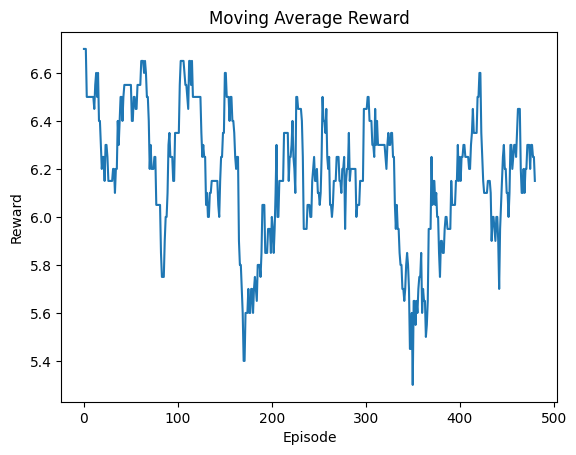

In [ ]:
window = 20
moving_avg = np.convolve(episode_rewards,
                         np.ones(window)/window,
                         mode='valid')

plt.figure()
plt.plot(moving_avg)
plt.title("Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

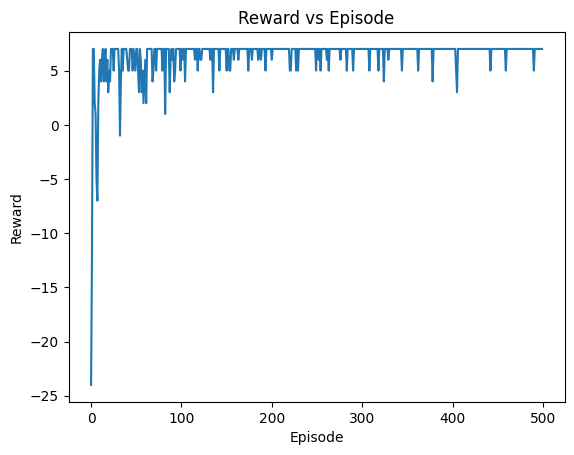

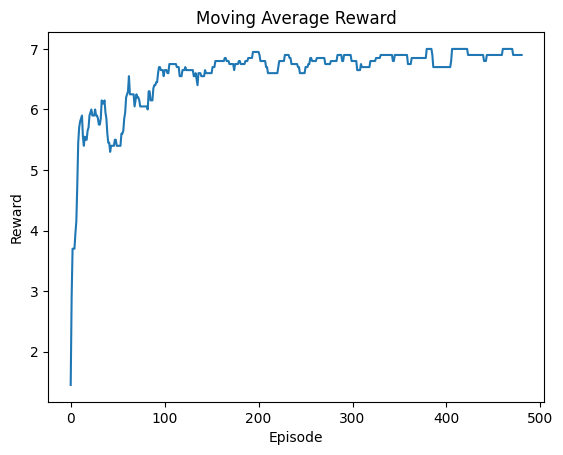

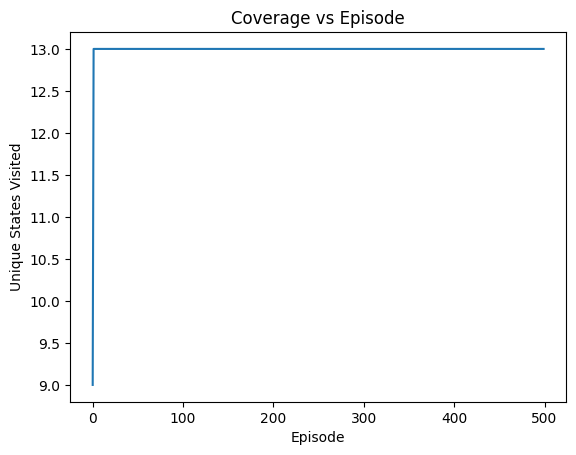

RL avg: 214.0
Random avg: -17.51
Avg steps RL: 3.0


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# -----------------------------
# GUI Grid
# -----------------------------
grid = [
['S','-','-','-','X'],
['-','-','-','-','X'],
['-','-','C','-','X'],
['-','-','-','-','G'],
['X','X','X','X','E']
]

ROWS = len(grid)
COLS = len(grid[0])

# -----------------------------
# Actions
# -----------------------------
actions = {
    0: (-1,0),   # up
    1: (1,0),    # down
    2: (0,-1),   # left
    3: (0,1)     # right
}

# -----------------------------
# Parameters
# -----------------------------
alpha = 0.1
gamma = 0.8
epsilon = 0.2
episodes = 500

Q = np.zeros((ROWS, COLS, 4))

# -----------------------------
# Reward function
# -----------------------------
def get_reward(r,c):
    if grid[r][c] == 'C':
        return 10
    elif grid[r][c] == 'G':
        return 5
    elif grid[r][c] == 'X':
        return -2
    else:
        return -1

# -----------------------------
# Move function
# -----------------------------
def move(r,c,action):
    dr,dc = actions[action]
    nr,nc = r+dr, c+dc

    if 0 <= nr < ROWS and 0 <= nc < COLS and grid[nr][nc] != 'X':
        return nr,nc
    return r,c

# -----------------------------
# Training
# -----------------------------
episode_rewards = []
coverage = []
visited = set()

for episode in range(episodes):

    r,c = 0,0
    total_reward = 0

    for step in range(50):

        visited.add((r,c))   # coverage tracking

        # epsilon-greedy
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr,nc = move(r,c,action)
        reward = get_reward(nr,nc)

        # Q update
        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r,c = nr,nc
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)
    coverage.append(len(visited))

    # epsilon decay
    epsilon = max(0.01, epsilon * 0.995)

# -----------------------------
# Plot Reward vs Episode
# -----------------------------
plt.figure()
plt.plot(episode_rewards)
plt.title("Reward vs Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# -----------------------------
# Moving Average
# -----------------------------
window = 20
moving_avg = np.convolve(
    episode_rewards,
    np.ones(window)/window,
    mode='valid'
)

plt.figure()
plt.plot(moving_avg)
plt.title("Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

# -----------------------------
# Coverage Plot
# -----------------------------
plt.figure()
plt.plot(coverage)
plt.title("Coverage vs Episode")
plt.xlabel("Episode")
plt.ylabel("Unique States Visited")
plt.show()

# -----------------------------
# RL vs Random
# -----------------------------
def random_agent():
    r,c = 0,0
    total = 0
    for _ in range(50):
        action = random.randint(0,3)
        r,c = move(r,c,action)
        total += get_reward(r,c)
    return total

# RL evaluation
def rl_agent():
    r,c = 0,0
    total = 0
    for _ in range(50):
        action = np.argmax(Q[r,c])
        r,c = move(r,c,action)
        total += get_reward(r,c)
        if grid[r][c] in ['G']:
            break
    return total

rl_scores = [rl_agent() for _ in range(100)]
rand_scores = [random_agent() for _ in range(100)]

print("RL avg:", np.mean(rl_scores))
print("Random avg:", np.mean(rand_scores))

# -----------------------------
# Crash discovery speed
# -----------------------------
def steps_rl():
    r,c=0,0
    for i in range(50):
        action = np.argmax(Q[r,c])
        r,c = move(r,c,action)
        if grid[r][c] in ['C','G']:
            return i
    return 50

print("Avg steps RL:", np.mean([steps_rl() for _ in range(50)]))

In [ ]:
symbols = {
    0: '↑',   # up
    1: '↓',   # down
    2: '←',   # left
    3: '→'    # right
}

print("\nOptimal Policy:\n")

for r in range(ROWS):
    row = []
    for c in range(COLS):

        if grid[r][c] == 'X':
            row.append('X')
        elif grid[r][c] == 'C':
            row.append('C')
        elif grid[r][c] == 'G':
            row.append('G')
        elif grid[r][c] == 'S':
            best_action = np.argmax(Q[r,c])
            row.append('S'+symbols[best_action])
        else:
            best_action = np.argmax(Q[r,c])
            row.append(symbols[best_action])

    print(row)


Optimal Policy:

['S→', '↓', '↓', '←', 'X']
['→', '→', '↓', '←', 'X']
['→', '→', 'C', '↑', 'X']
['↓', '↑', '↑', '↑', 'G']
['X', 'X', 'X', 'X', '↑']


# ***Custom Grid Setup(dynamic)***

---



---

In [ ]:
def randomize_environment():
    # remove C and G
    for r in range(ROWS):
        for c in range(COLS):
            if grid[r][c] in ['C','G']:
                grid[r][c] = '-'

    # place new crash
    while True:
        r = random.randint(0,ROWS-1)
        c = random.randint(0,COLS-1)
        if grid[r][c] == '-':
            grid[r][c] = 'C'
            break

    # place new goal
    while True:
        r = random.randint(0,ROWS-1)
        c = random.randint(0,COLS-1)
        if grid[r][c] == '-':
            grid[r][c] = 'G'
            break

In [ ]:
if episode % 75 == 0:
    randomize_environment()

In [ ]:
def print_grid(grid, episode):
    print("\nEnvironment changed at episode:", episode)
    for row in grid:
        print(row)

In [ ]:
for episode in range(episodes):

    if episode % 75 == 0:
        randomize_environment()
        print_grid(grid, episode)

    r, c = 0, 0


Environment changed at episode: 0
['S', 'C', '-', '-', 'X']
['-', '-', 'G', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 75
['S', '-', '-', '-', 'X']
['-', '-', '-', 'G', 'X']
['-', '-', '-', '-', 'X']
['-', '-', 'C', '-', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 150
['S', '-', 'G', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', 'C', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 225
['S', '-', '-', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', 'C', '-', 'X']
['G', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 300
['S', '-', '-', '-', 'X']
['-', '-', '-', '-', 'X']
['G', '-', '-', '-', 'X']
['-', '-', 'C', '-', '-']
['X', 'X', 'X', 'X', 'E']

Environment changed at episode: 375
['S', '-', 'G', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', 'C', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']



# ***RL training on (dynamic) GUI Grid***

---



---


In [ ]:
episode_rewards = []

for episode in range(episodes):

    # change GUI dynamically
    if episode % 75 == 0:
        randomize_environment()


        # encourage re-exploration
        epsilon = 0.3

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        # epsilon-greedy
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        # Q-learning update
        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        # stop if crash or goal reached
        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)

    # decay epsilon
    epsilon = max(0.05, epsilon * 0.995)

In [ ]:
symbols = {0:'↑',1:'↓',2:'←',3:'→'}

print("\nFinal Learned Policy:\n")

for r in range(ROWS):
    row = []
    for c in range(COLS):
        if grid[r][c] in ['X','C','G']:
            row.append(grid[r][c])
        else:
            row.append(symbols[np.argmax(Q[r,c])])
    print(row)


Final Learned Policy:

['→', 'C', '←', '←', 'X']
['→', '↓', '←', '←', 'X']
['→', '↑', '←', '↑', 'X']
['G', '↑', '↑', '→', '↑']
['X', 'X', 'X', 'X', '↑']


In [ ]:
import numpy as np
import random

# -----------------------------
# Dynamic randomization (your code)
# -----------------------------
def randomize_environment():
    # remove C and G
    for r in range(ROWS):
        for c in range(COLS):
            if grid[r][c] in ['C','G']:
                grid[r][c] = '-'

    # place new crash
    while True:
        r = random.randint(0,ROWS-1)
        c = random.randint(0,COLS-1)
        if grid[r][c] == '-':
            grid[r][c] = 'C'
            break

    # place new goal
    while True:
        r = random.randint(0,ROWS-1)
        c = random.randint(0,COLS-1)
        if grid[r][c] == '-':
            grid[r][c] = 'G'
            break


def print_grid(grid, episode):
    print("\nEnvironment changed at episode:", episode)
    for row in grid:
        print(row)


# -----------------------------
# Training
# -----------------------------
episode_rewards = []

for episode in range(episodes):

    # Print reward BEFORE changing environment
    if episode % 75 == 0 and episode > 0:
        avg_reward = np.mean(episode_rewards[-75:])
        print("\n--------------------------------")
        print("Average reward before change:", round(avg_reward,2))

        randomize_environment()
        print_grid(grid, episode)

        # encourage re-exploration
        epsilon = 0.3

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        # epsilon-greedy
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        # Q-learning update
        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        # stop if crash or goal reached
        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)

    # decay epsilon
    epsilon = max(0.05, epsilon * 0.995)


--------------------------------
Average reward before change: 9.28

Environment changed at episode: 75
['S', '-', '-', '-', 'X']
['-', '-', 'C', '-', 'X']
['-', 'G', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

--------------------------------
Average reward before change: 6.01

Environment changed at episode: 150
['S', '-', '-', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', '-', 'X']
['-', '-', 'C', 'G', '-']
['X', 'X', 'X', 'X', 'E']

--------------------------------
Average reward before change: -2.23

Environment changed at episode: 225
['S', '-', '-', '-', 'X']
['-', '-', '-', '-', 'X']
['C', '-', '-', 'G', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

--------------------------------
Average reward before change: 6.93

Environment changed at episode: 300
['S', '-', 'C', '-', 'X']
['-', '-', '-', 'G', 'X']
['-', '-', '-', '-', 'X']
['-', '-', '-', '-', '-']
['X', 'X', 'X', 'X', 'E']

--------------------------------
Average reward before 

In [ ]:
def print_policy(Q, grid, episode=None):
    symbols = {0:'↑',1:'↓',2:'←',3:'→'}

    if episode is not None:
        print("\nLearned policy at episode:", episode)

    for r in range(ROWS):
        row = []
        for c in range(COLS):

            if grid[r][c] == 'X':
                row.append('X')
            elif grid[r][c] == 'C':
                row.append('C')
            elif grid[r][c] == 'G':
                row.append('G')
            else:
                best_action = np.argmax(Q[r,c])
                row.append(symbols[best_action])

        print(row)

In [ ]:
for episode in range(episodes):

    r, c = 0, 0

    for step in range(50):
        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc

        if grid[r][c] in ['C','G']:
            break

    epsilon = max(0.05, epsilon*0.995)

    # change environment
    if episode % 75 == 0:
        randomize_environment()

    # show learned arrows
    if episode % 75 == 74:
        print_policy(Q, grid, episode)


Learned policy at episode: 74
['→', '→', 'G', '↓', 'X']
['↑', '↓', '↓', '↓', 'X']
['→', '→', '→', 'C', 'X']
['←', '↓', '↑', '→', '↑']
['X', 'X', 'X', 'X', '↑']

Learned policy at episode: 149
['→', '→', '↓', '→', 'X']
['↑', '↓', 'C', '↓', 'X']
['G', '→', '↑', '←', 'X']
['←', '↓', '↑', '↓', '↑']
['X', 'X', 'X', 'X', '↓']

Learned policy at episode: 224
['→', 'G', '↓', 'C', 'X']
['↑', '↓', '↑', '↓', 'X']
['→', '→', '↑', '↑', 'X']
['←', '↓', '↑', '↓', '↑']
['X', 'X', 'X', 'X', '↓']

Learned policy at episode: 299
['→', 'C', '↓', '→', 'X']
['↑', '↓', '↑', '↓', 'X']
['→', '→', '↑', '↑', 'X']
['←', '↓', 'G', '↓', '↑']
['X', 'X', 'X', 'X', '↓']

Learned policy at episode: 374
['→', '→', '→', 'C', 'X']
['↑', '↑', '↑', '←', 'X']
['→', '→', '↑', '↓', 'X']
['←', '↓', '↑', '↓', 'G']
['X', 'X', 'X', 'X', '↓']

Learned policy at episode: 449
['↓', '→', '↓', '↑', 'X']
['→', '↓', '↓', '←', 'X']
['→', '→', 'G', '←', 'X']
['←', 'C', '↑', '→', '↑']
['X', 'X', 'X', 'X', '↓']


In [ ]:
change_points = []
episode_rewards = []

In [ ]:
if episode % 75 == 0 and episode > 0:
    change_points.append(episode)

    avg_reward = np.mean(episode_rewards[-75:])
    print("Avg reward before change:", round(avg_reward,2))

    randomize_environment()
    print_grid(grid, episode)

    epsilon = 0.3

# ***Transfer learning (Testing on a diffrent GUI Grid)***

---



---


In [ ]:
Q_transfer = Q.copy()

In [ ]:
grid_B = [
['S','-','-','-','X'],
['X','X','-','X','X'],
['-','-','-','-','X'],
['-','C','-','-','G'],
['X','X','X','X','E']
]

In [ ]:
Q = Q_transfer
epsilon = 0.3

transfer_rewards = []

for episode in range(100):

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    transfer_rewards.append(total_reward)
    epsilon = max(0.05, epsilon*0.995)

In [ ]:
Q_scratch = np.zeros((ROWS,COLS,4))
epsilon = 0.3
scratch_rewards = []

for episode in range(100):

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q_scratch[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        Q_scratch[r,c,action] += alpha * (
            reward + gamma*np.max(Q_scratch[nr,nc]) - Q_scratch[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    scratch_rewards.append(total_reward)
    epsilon = max(0.05, epsilon*0.995)

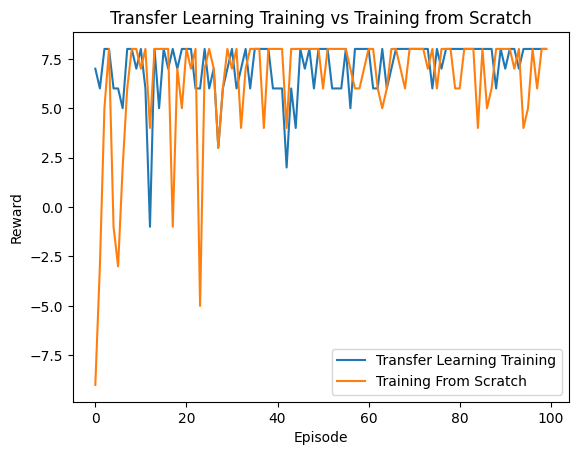

In [ ]:
import matplotlib.pyplot as plt

plt.plot(transfer_rewards, label="Transfer Learning Training")
plt.plot(scratch_rewards, label="Training From Scratch")
plt.legend()
plt.title("Transfer Learning Training vs Training from Scratch")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

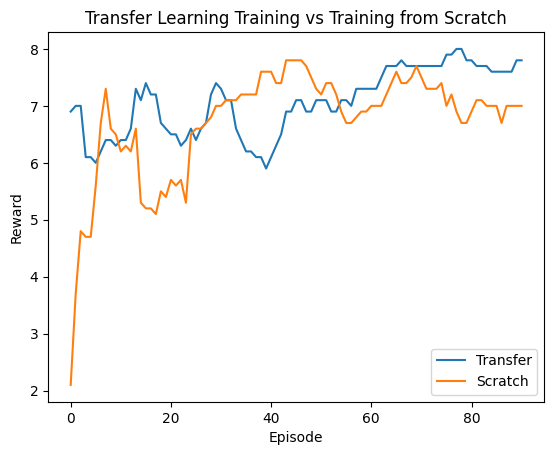

In [ ]:
window = 10

transfer_smooth = np.convolve(
    transfer_rewards,
    np.ones(window)/window,
    mode='valid'
)

scratch_smooth = np.convolve(
    scratch_rewards,
    np.ones(window)/window,
    mode='valid'
)

import matplotlib.pyplot as plt

plt.plot(transfer_smooth, label="Transfer")
plt.plot(scratch_smooth, label="Scratch")
plt.legend()
plt.title("Transfer Learning Training vs Training from Scratch")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

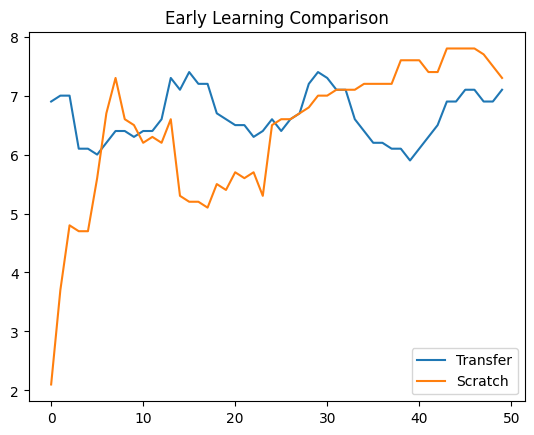

In [ ]:
plt.plot(transfer_smooth[:50], label="Transfer")
plt.plot(scratch_smooth[:50], label="Scratch")
plt.legend()
plt.title("Early Learning Comparison")
plt.show()

In [ ]:
print("Transfer avg first 50:",
      np.mean(transfer_rewards[:50]))

print("Scratch avg first 50:",
      np.mean(scratch_rewards[:50]))

Transfer avg first 50: 6.64
Scratch avg first 50: 5.72


In [ ]:
threshold = 5

transfer_ep = next(i for i,v in enumerate(transfer_smooth) if v > threshold)
scratch_ep = next(i for i,v in enumerate(scratch_smooth) if v > threshold)

print("Transfer reaches threshold at:", transfer_ep)
print("Scratch reaches threshold at:", scratch_ep)

Transfer reaches threshold at: 0
Scratch reaches threshold at: 5


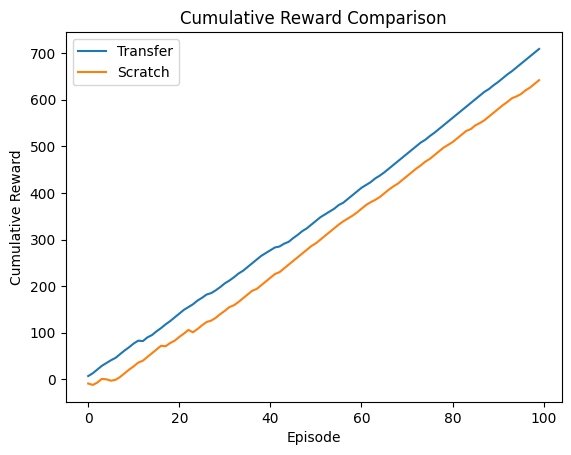

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.plot(np.cumsum(transfer_rewards), label="Transfer")
plt.plot(np.cumsum(scratch_rewards), label="Scratch")
plt.legend()
plt.title("Cumulative Reward Comparison")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.show()

In [ ]:
print("Transfer total first 50:",
      np.sum(transfer_rewards[:50]))

print("Scratch total first 50:",
      np.sum(scratch_rewards[:50]))

Transfer total first 50: 332
Scratch total first 50: 286


In [ ]:
visit_count = np.zeros((ROWS, COLS))

# inside training loop
visit_count[r,c] += 1

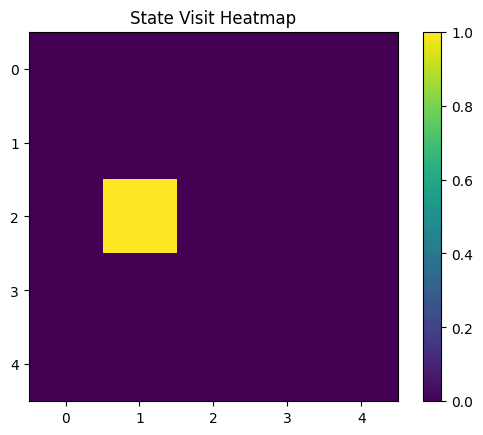

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(visit_count)
plt.title("State Visit Heatmap")
plt.colorbar()
plt.show()

In [ ]:
#trying to addStochastic behaviour. following codes-debug


In [ ]:
def move(r, c, action):
    slip_prob = 0.15
    original_action = action

    if random.random() < slip_prob:
        action = random.randint(0,3)
        print(f"Slip! Intended: {original_action}, Actual: {action}")

    dr, dc = actions[action]
    nr = r + dr
    nc = c + dc

    if 0 <= nr < ROWS and 0 <= nc < COLS:
        if grid[nr][nc] != 'X':
            return nr, nc

    return r, c

In [ ]:
episode_rewards = []

for episode in range(episodes):

    # change GUI dynamically
    if episode % 75 == 0:
        randomize_environment()
        epsilon = 0.3

    r, c = 0, 0
    total_reward = 0

    for step in range(50):

        if random.uniform(0,1) < epsilon:
            action = random.randint(0,3)
        else:
            action = np.argmax(Q[r,c])

        nr, nc = move(r,c,action)
        reward = get_reward(nr,nc)

        Q[r,c,action] += alpha * (
            reward + gamma*np.max(Q[nr,nc]) - Q[r,c,action]
        )

        r, c = nr, nc
        total_reward += reward

        if grid[r][c] in ['C','G']:
            break

    episode_rewards.append(total_reward)

    epsilon = max(0.05, epsilon * 0.995)

In [ ]:
slip_count = 0
total_moves = 0

In [ ]:
def move(r, c, action):
    global slip_count, total_moves
    total_moves += 1

    if random.random() < 0.15:
        slip_count += 1
        action = random.randint(0,3)

In [ ]:
print("Slip rate:", slip_count / total_moves)

ZeroDivisionError: division by zero